# CHƯƠNG 1: GIỚI THIỆU
## 1.1. Mục tiêu
Sau khi hoàn thành bài thực hành này, sinh viên có thể:
- Hiểu bài toán hồi quy (regression)
- Thực hiện pipeline Machine Learning cho bài toán regression
- Huấn luyện nhiều mô hình regression khác nhau
- Đánh giá mô hình bằng các chỉ số MAE, RMSE, và R2
- Thực hiện feature engineering và hyperparameter tuning
## 1.2. Giới thiệu bài toán
Trong bài thực hành này, chúng ta sẽ giải quyết bài toán:
Dự đoán giá nhà dựa trên các đặc trưng của căn nhà.

Dataset sử dụng:
House Prices- Advanced Regression Techniques
Dataset được cung cấp trên Kaggle.
Dataset bao gồm nhiều thông tin như:
- diện tích nhà
- năm xây dựng
- số phòng
- vị trí
- chất lượng vật liệu

Mục tiêu của mô hình là dự đoán biến:
SalePrice

# CHƯƠNG 2: KHÁM PHÁ DỮ LIỆU

## 2.1. Tải dữ liệu

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

## 2.2. Chuẩn bị dữ liệu

In [2]:
train = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')

In [3]:
print("Kích thước tệp train:", train.shape)
train.head()

Kích thước tệp train: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Sau khi khởi tạo dữ liệu ban đầu, ta thấy được kích thước tệp train sẽ là 1460 dòng và 81 cột.
81 cột này sẽ tương ứng với 81 đặc trưng như đã liệt kê ở trên.

In [4]:
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## 2.3. Kiểm tra dữ liệu
Để kiểm tra dữ liệu bị thiếu, ta sử dụng lệnh train.isnull().sum().
Kết quả trả về ta thấy được 19 dữ liệu bị khuyết, trong đó PoolQC bị khuyết nhiều nhất với tỉ lệ phần trăm chiếm tận 99.5%.

In [5]:
pd.set_option('display.max_rows', None)
null_counts=train.isnull().sum()
missing_percentage = (null_counts / len(train)) * 100
missing_data = pd.DataFrame({
    'Total Missing': null_counts,
    'Percentage (%)': missing_percentage
})
missing_data = missing_data[missing_data['Total Missing'] > 0].sort_values(by='Percentage (%)', ascending=False)
print(missing_data)

              Total Missing  Percentage (%)
PoolQC                 1453       99.520548
MiscFeature            1406       96.301370
Alley                  1369       93.767123
Fence                  1179       80.753425
MasVnrType              872       59.726027
FireplaceQu             690       47.260274
LotFrontage             259       17.739726
GarageType               81        5.547945
GarageYrBlt              81        5.547945
GarageFinish             81        5.547945
GarageQual               81        5.547945
GarageCond               81        5.547945
BsmtExposure             38        2.602740
BsmtFinType2             38        2.602740
BsmtQual                 37        2.534247
BsmtCond                 37        2.534247
BsmtFinType1             37        2.534247
MasVnrArea                8        0.547945
Electrical                1        0.068493


## 2.4. Thống kê dữ liệu

### 2.4.1. Historgram SalePrice
Dữ liệu biến mục tiêu - giá nhà trong tệp huấn luyện được trải dài từ khoảng 50000 tới 700000. Phân bố tập trung trong khoảng từ 100000 đến 200000. Biểu đồ phân bố lệch về bên trái cho thấy giá nhà ở mức trung bình thấp. Có một số ít ngôi nhà có giá rất cao kéo dài về phía bên phải.

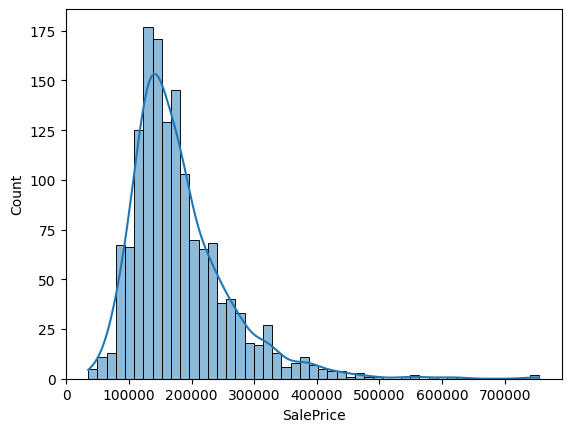

In [6]:
sns.histplot(train['SalePrice'], kde=True)
plt.show()

### 2.4.2. Biểu đồ Scatter giữa GrLivArea và SalePrice
Có mối tương quan tuyến tính, diện tích đất nền càng lớn thì giá nhà càng cao. Xuất hiện các điểm dữ liệu có diện tích rất lớn nhưng giá lại cực thấp.

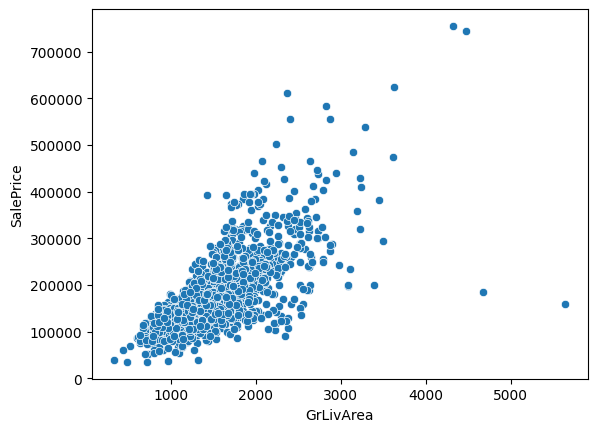

In [7]:
sns.scatterplot(x='GrLivArea', y='SalePrice', data=train)
plt.show()

### 2.4.3 Biểu đồ Scatter giữa OverallQual và SalePrice
Khi mức độ chất lượng từ 1 đến 10, giá nhà cũng tăng theo cấp số nhân. Ở mức chất lượng 10, giá nhà có biên độ dao động rất lớn. Với mức từ 8-10, ta thấy giá nhà tăng vọt.

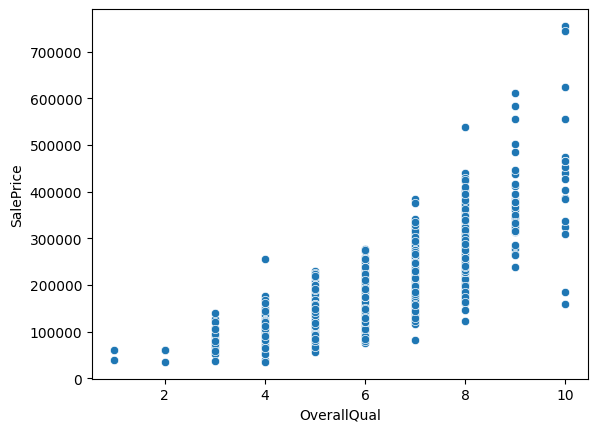

In [8]:
sns.scatterplot(x='OverallQual', y='SalePrice', data=train)
plt.show()

## 2.5. Tương quan giữa các biến

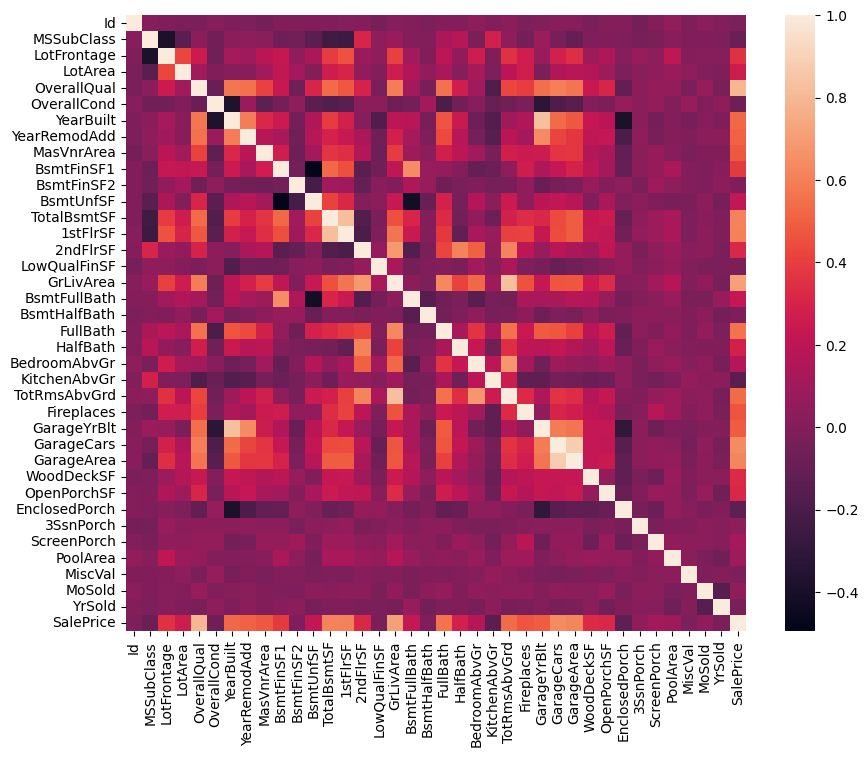

In [9]:
corr = train.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr)
plt.show()


Dưới đây là 10 Feature có tương quan cao nhất với SalePrice. Trong đó có 2 biến đã khảo sát là SalePrice và OverallQual.

In [10]:
corr['SalePrice'].sort_values(ascending=False).head(11)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

## 2.6 Chọn Feature đặc trưng
Ta chọn các feature quan trọng sau để huấn luyện
- OverallQual: Đánh giá tổng thể vật liệu và độ hoàn thiện.
- GrLivArea: Tổng diện tích sàn trên mặt đất.
- TotalBsmtSF: Tổng diện tích tầng hầm.
- GarageCars: Sức chứa xe của gara.
- YearBuilt: Năm xây dựng của ngôi nhà.
- FullBath: Số lượng phòng tắm đầy đủ.
- Neighborhood: Vị trí địa lý.
- ExterQual: Chất lượng vật liệu bên ngoài.
- KitchenQual: Chất lượng phòng bếp. 
- Foundation: Loại móng nhà.


In [11]:
features = [
    'OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 
    'FullBath', 'Neighborhood', 'ExterQual', 'KitchenQual', 'Foundation',
    '1stFlrSF', '2ndFlrSF']
X = train[features]
y = train['SalePrice']

# CHƯƠNG 3: HUẤN LUYỆN MÔ HÌNH

In [12]:
X_train, X_val, y_train, y_val = train_test_split(
X, y, test_size=0.2, random_state=42)


## 3.1. Linear Regression

In [13]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_val = pd.get_dummies(X_val, drop_first=True)

#Đồng bộ các cột giữa tập train và tập val 
X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)

lr = LinearRegression()
lr.fit(X_train, y_train)
pred = lr.predict(X_val)

mae = mean_absolute_error(y_val, pred)
rmse = np.sqrt(mean_squared_error(y_val, pred))
r2 = r2_score(y_val, pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 21153.010365335824
RMSE: 33949.2986956135
R2: 0.8497384790696338


## 3.2 Random Forest Regressor

In [14]:
rf = RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_val)

mae = mean_absolute_error(y_val, pred_rf)
rmse = np.sqrt(mean_squared_error(y_val, pred_rf))
r2 = r2_score(y_val, pred_rf)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

scores = cross_val_score(rf, X_val, y_val, cv=5)
mean_score = scores.mean()
print("Điểm R2 của từng fold:", scores)
print(f"Giá trị trung bình: {mean_score:.4f}")

MAE: 17997.469103473584
RMSE: 27779.96891697192
R2: 0.899388024422636
Điểm R2 của từng fold: [0.79375415 0.85499876 0.83456863 0.74058529 0.91204866]
Giá trị trung bình: 0.8272


## 3.3 Ridge Regression

In [15]:
rr = Ridge(alpha=1.0)
rr.fit(X_train, y_train)
pred_rr = rr.predict(X_val)

mae = mean_absolute_error(y_val, pred_rr)
rmse = np.sqrt(mean_squared_error(y_val, pred_rr))
r2 = r2_score(y_val, pred_rr)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 21050.546461995422
RMSE: 33892.95628611039
R2: 0.8502368146043355


## 3.4 Lasso Regression

In [16]:
lm = Lasso(alpha=0.1)
lm.fit(X_train, y_train)
pred_lm = lm.predict(X_val)

mae = mean_absolute_error(y_val, pred_lm)
rmse = np.sqrt(mean_squared_error(y_val, pred_lm))
r2 = r2_score(y_val, pred_lm)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 21150.860114750445
RMSE: 33948.33931551627
R2: 0.8497469714910507


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.163e+11, tolerance: 6.967e+08
  model = cd_fast.enet_coordinate_descent(


## 3.5. Decision Tree Regressor

In [17]:
tg = DecisionTreeRegressor(max_depth=5, random_state=42)
tg.fit(X_train, y_train)
pred_tg = tg.predict(X_val)

mae = mean_absolute_error(y_val, pred_tg)
rmse = np.sqrt(mean_squared_error(y_val, pred_tg))
r2 = r2_score(y_val, pred_tg)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 25573.04986738103
RMSE: 36492.466889274074
R2: 0.8263828546930695


# CHƯƠNG 4: CẢI THIỆN MÔ HÌNH
## 4.1. Hyperparameter Tuning

In [19]:
rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300, None],
    'max_depth': [5, 10, 20]
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)

grid_search.fit(X_train, y_train)

print("Tham số tốt nhất tìm được:", grid_search.best_params_)
print(f"Điểm R2 tốt nhất trên tập train (CV): {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_
pred_best = best_rf.predict(X_val)

from sklearn.metrics import r2_score
print(f"Điểm R2 trên tập Validation sau khi Tuning: {r2_score(y_val, pred_best):.4f}")
print(f"R2 trên tập Validation sau khi Tuning: {r2_score(y_val, pred_best)}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_

Tham số tốt nhất tìm được: {'max_depth': 20, 'n_estimators': 200}
Điểm R2 tốt nhất trên tập train (CV): 0.8231
Điểm R2 trên tập Validation sau khi Tuning: 0.8973
R2 trên tập Validation sau khi Tuning: 0.8973413126192984


## 4.2 Feature Engineering

In [20]:
X_train['AgeOfHouse'] = 2024 - X_train['YearBuilt']
X_train['TotalArea'] = X_train['TotalBsmtSF'] + X_train['1stFlrSF'] + X_train['2ndFlrSF']

X_val['AgeOfHouse'] = 2024 - X_val['YearBuilt']
X_val['TotalArea'] = X_val['TotalBsmtSF'] + X_val['1stFlrSF'] + X_val['2ndFlrSF']

rf_new = RandomForestRegressor(random_state=42)
rf_new.fit(X_train, y_train)

pred_new = rf_new.predict(X_val)
r2_new = r2_score(y_val, pred_new)

print(f"Điểm R2 mới trên tập Validation: {r2_new:.4f}")

Điểm R2 mới trên tập Validation: 0.8848


## 4.3. Cải thiện mô hình 

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(random_state=42)

param_grid_gbr = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4, 5]
}

grid_gbr = GridSearchCV(estimator=gbr, param_grid=param_grid_gbr, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_gbr.fit(X_train, y_train)

best_gbr_model = grid_gbr.best_estimator_

pred_gbr = best_gbr_model.predict(X_val)

mae_gbr = mean_absolute_error(y_val, pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_val, pred_gbr))
r2_gbr = r2_score(y_val, pred_gbr)

print("Tham số tối ưu tìm được:", grid_gbr.best_params_)
print(f"MAE  : {mae_gbr}")
print(f"RMSE : {rmse_gbr}")
print(f"R2   : {r2_gbr}")